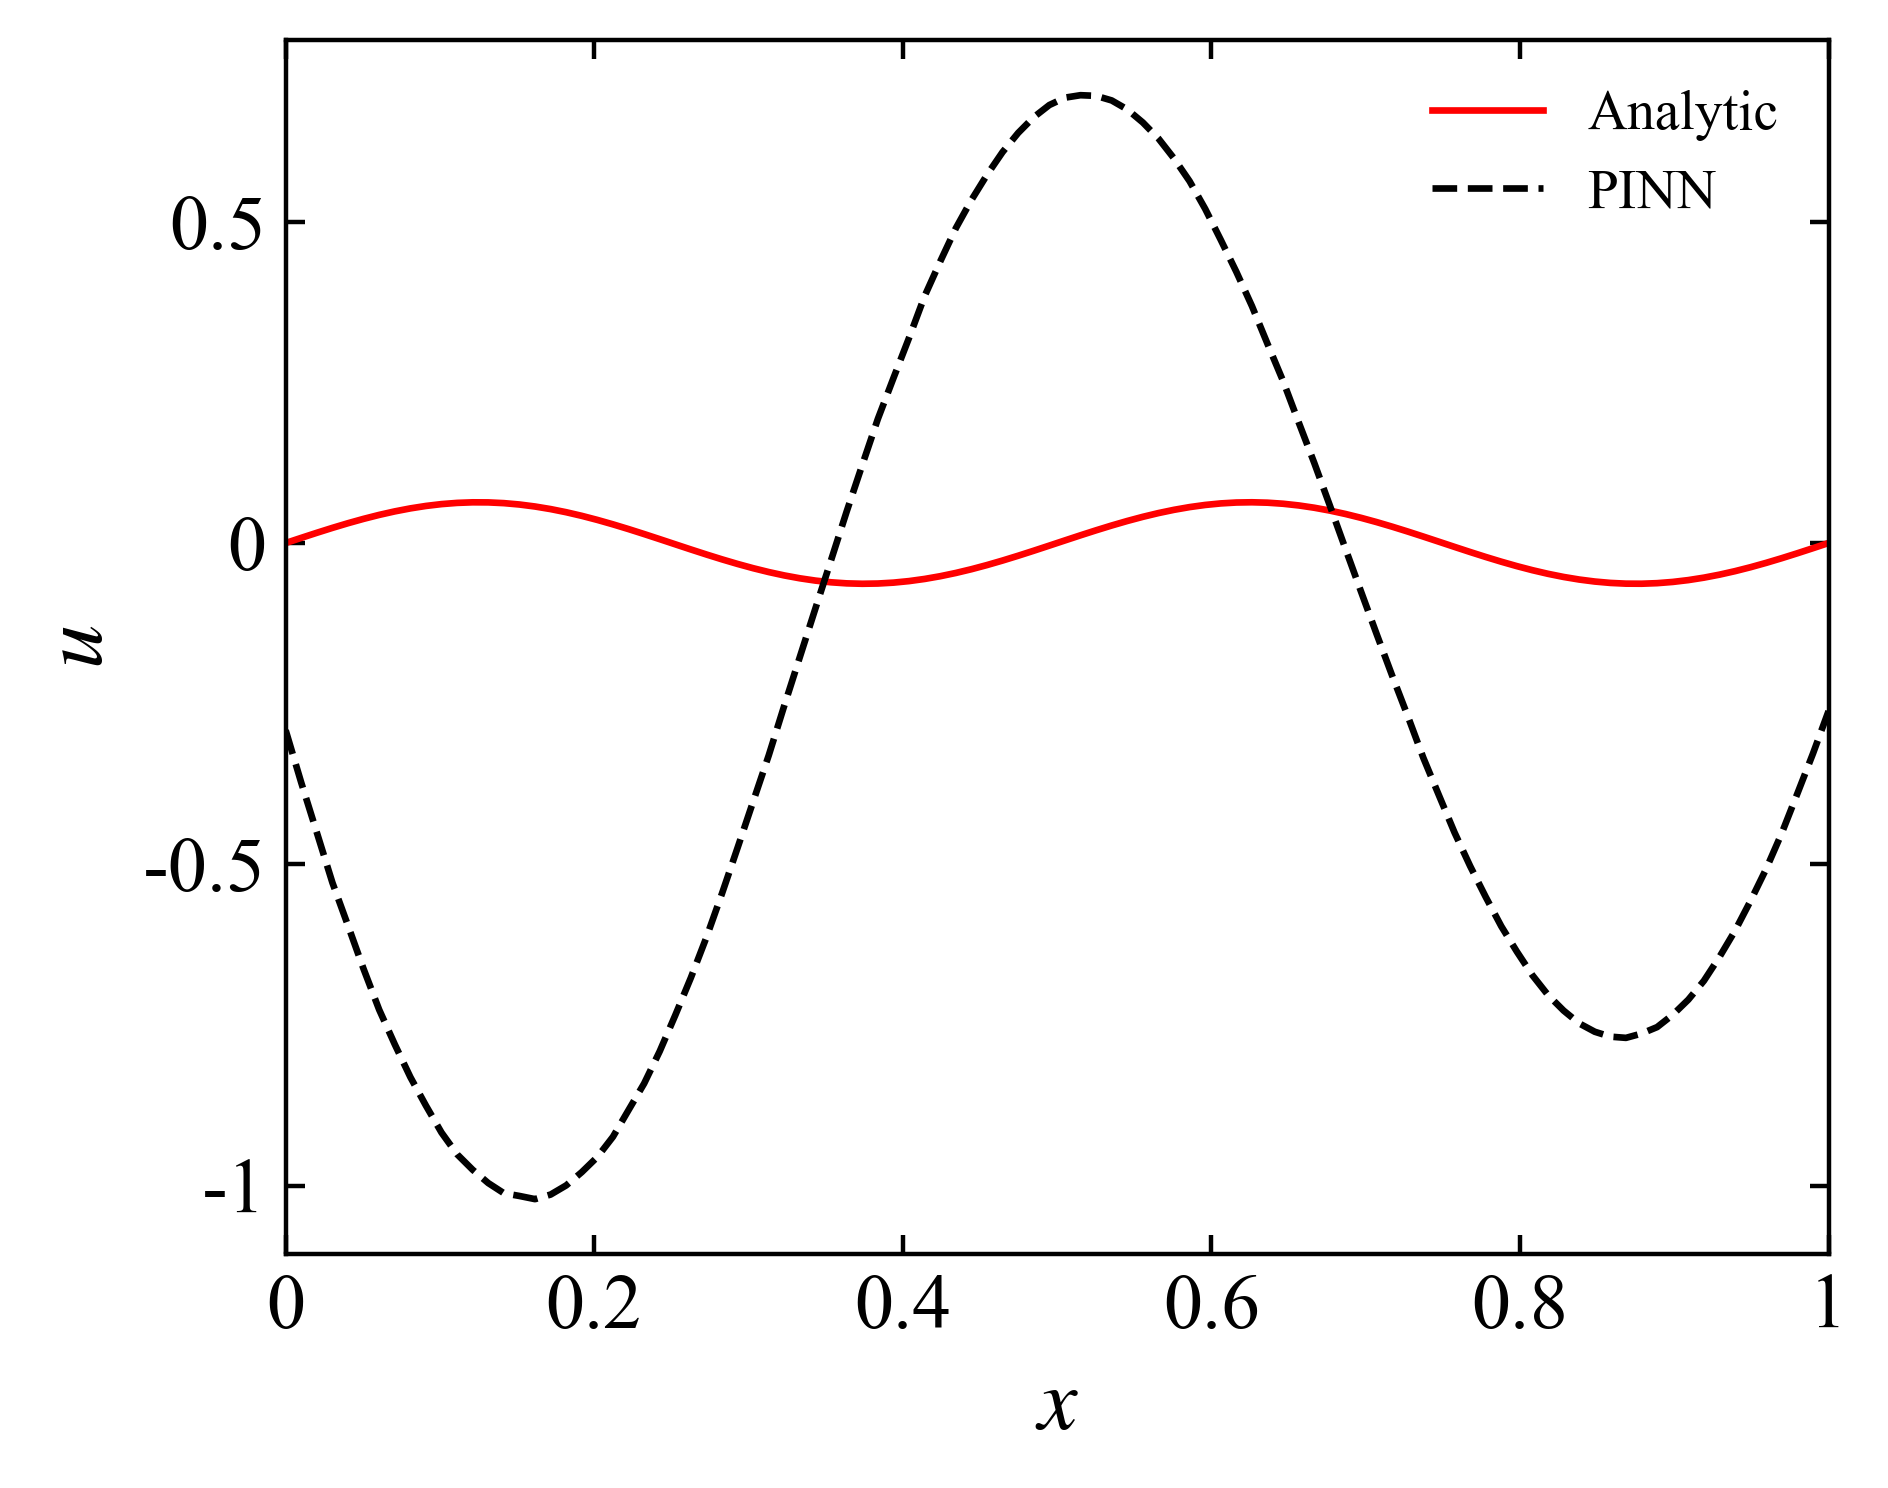

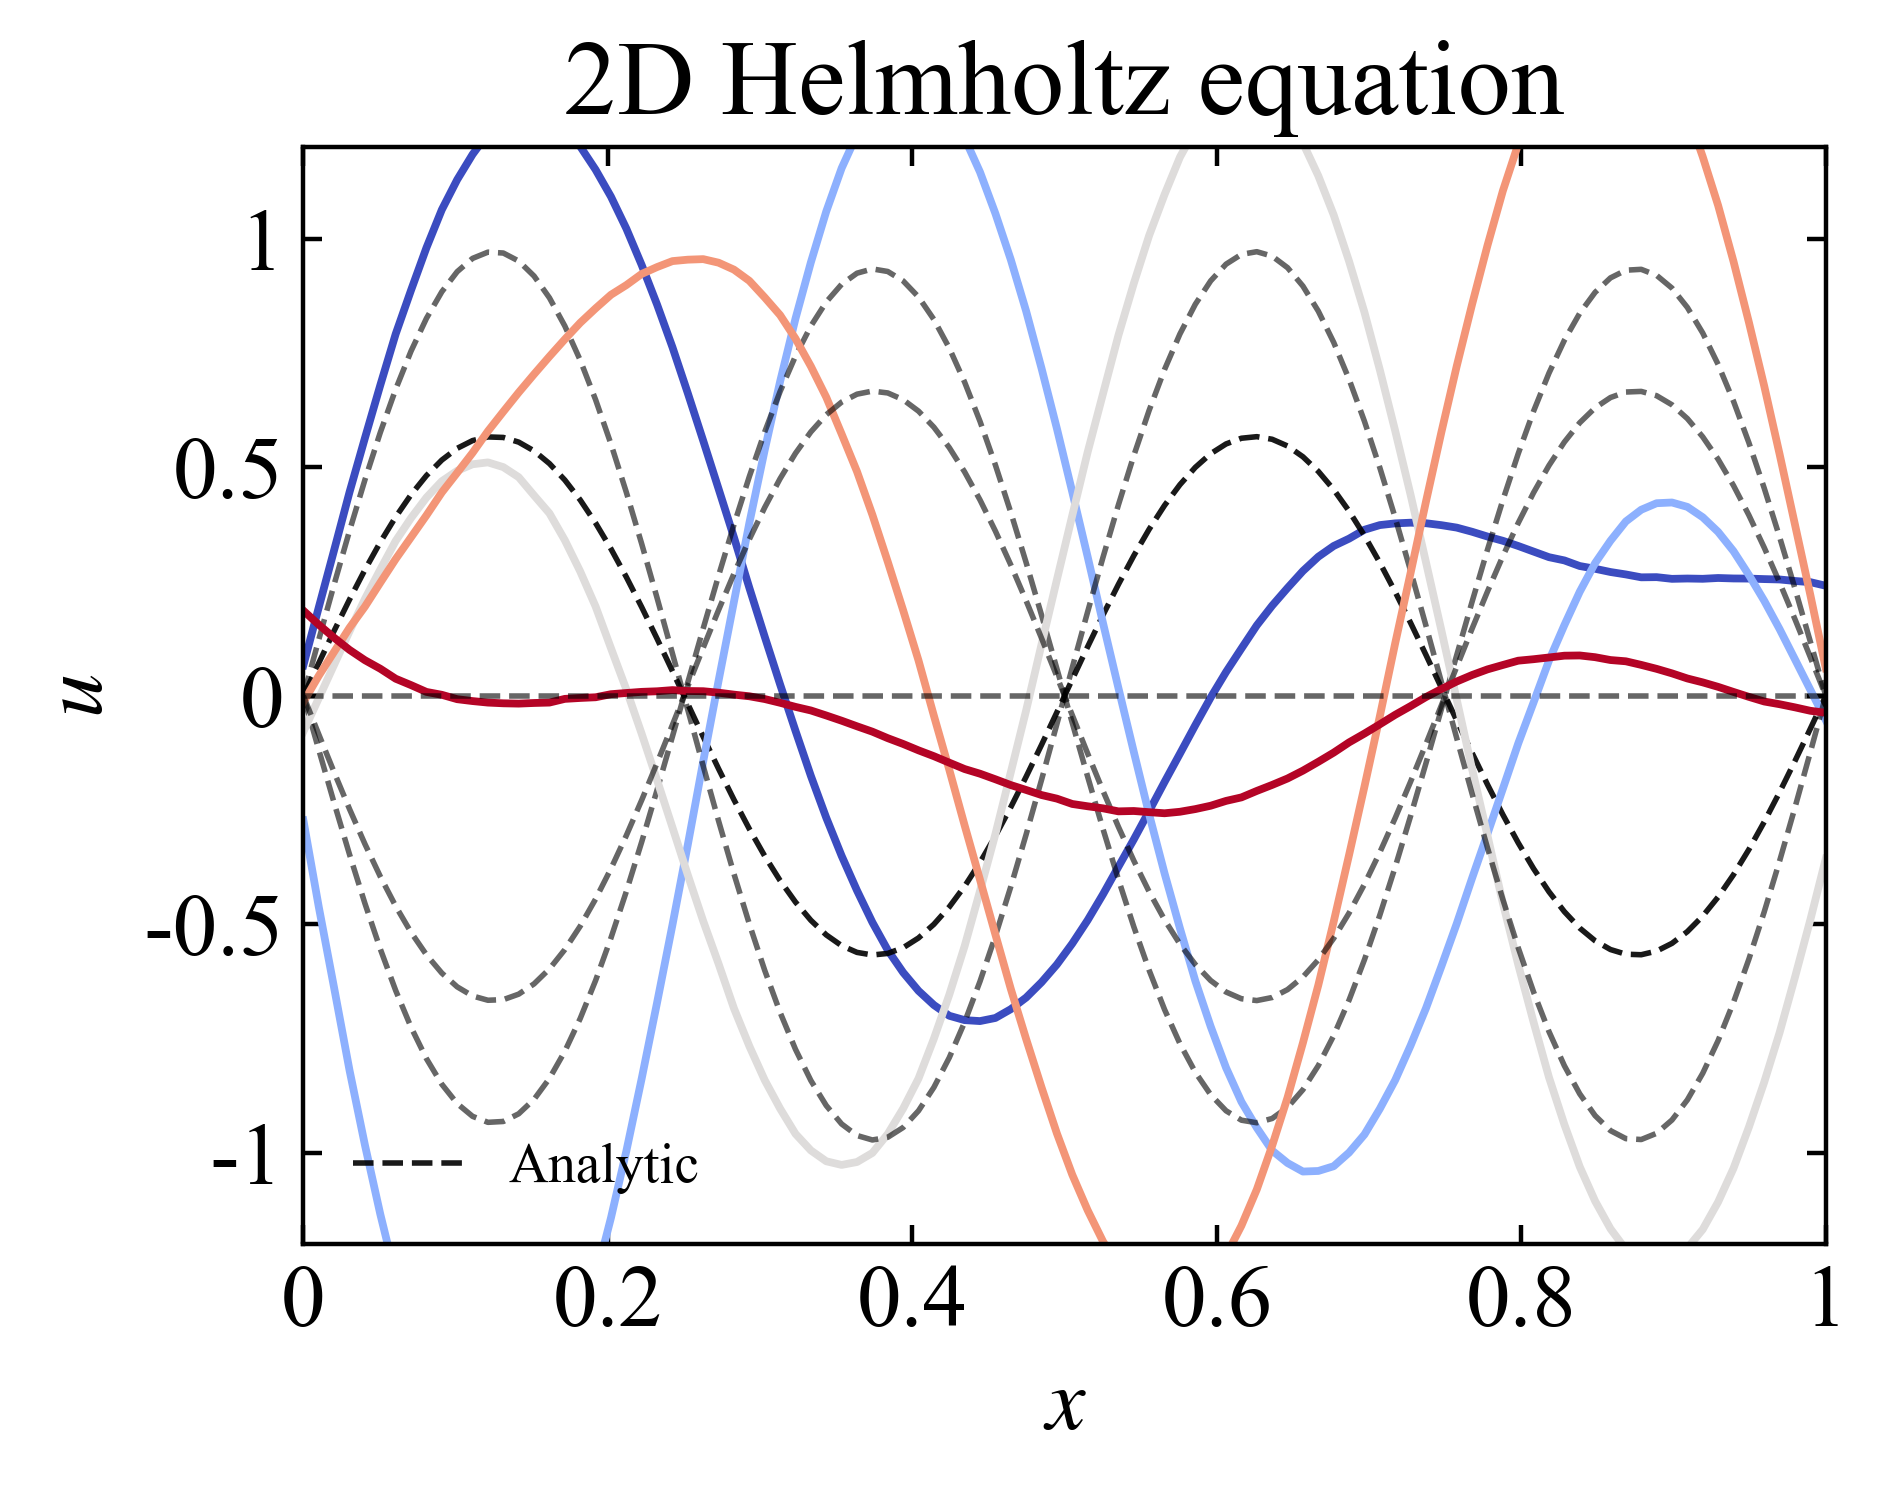

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

# ── 스타일 ─────────────────────────────────────────
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.dpi'] = 400

condition_set = (2,10)
exact = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/exact_LPA.txt', delimiter=',').ravel()
prediction = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/prediction_LPA.txt', delimiter=',').ravel()

# ── 격자/도메인 설정 ───────────────────────────────
nx, ny = 100, 100                 # ← 실제 저장 크기에 맞게 수정
X_RANGE = (-0, 1.0)             # ← x 범위 (모르면 (0,1))
Y_RANGE = (-0, 1.0)             # ← y 범위 (참고용)
x = np.linspace(X_RANGE[0], X_RANGE[1], nx)
y = np.linspace(Y_RANGE[0], Y_RANGE[1], ny)

EX = exact.reshape(ny, nx)
PR = prediction.reshape(ny, nx)

# 정수면 소수점 제거 포매터
def no_dot_if_int(v, pos):
    return f"{int(v)}" if float(v).is_integer() else f"{v:g}"
formatter = FuncFormatter(no_dot_if_int)

# ── (A) 기본: y = 중간 단면에서 u(x) 비교 ─────────────────────────────
j = ny // 2  # 중간 y-index (원하면 다른 인덱스로 변경)

plt.figure(figsize=(5,4))
plt.plot(x, EX[j, :], label='Analytic', linestyle='-',  linewidth=1.2, color='red')
plt.plot(x, PR[j, :], label='PINN',     linestyle='--', linewidth=1.2, color='black')
plt.xlabel('$x$'); plt.ylabel('$u$')
plt.xlim(X_RANGE)
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.legend(fontsize=10, loc='best', frameon=False, ncol=1)
plt.tight_layout()
plt.show()

# ── (B) 옵션: 여러 y-슬라이스에서 u(x) 비교 (색만 달리 표시) ───────────
# 사용하려면 주석 해제
y_idx_list = [ny//5, 2*ny//5, 3*ny//5, 4*ny//5, 5*ny//5-1]
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=ny//5, vmax=5*ny//5-1)
plt.figure(figsize=(5,4))
for jj in y_idx_list:
    c = cmap(norm(jj))
    plt.plot(x, PR[jj, :], color=c,     lw=1.4, label=None)
    plt.plot(x, EX[jj, :], color='k',   ls='--', lw=1.0, alpha=0.9 if jj==y_idx_list[0] else 0.6,
             label='Analytic' if jj==y_idx_list[0] else None)
    
plt.xlabel('$x$'); plt.ylabel('$u$')
plt.xlim(X_RANGE)
plt.tick_params(axis='both', which='major', direction='in', labelsize=16, top=True, right=True)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
# 필요하면 범례 표시
plt.ylim(-1.2, 1.2)
plt.title("2D Helmholtz equation")
plt.legend(fontsize=10, loc='best', frameon=False, ncol=1)
plt.tight_layout(); plt.show()


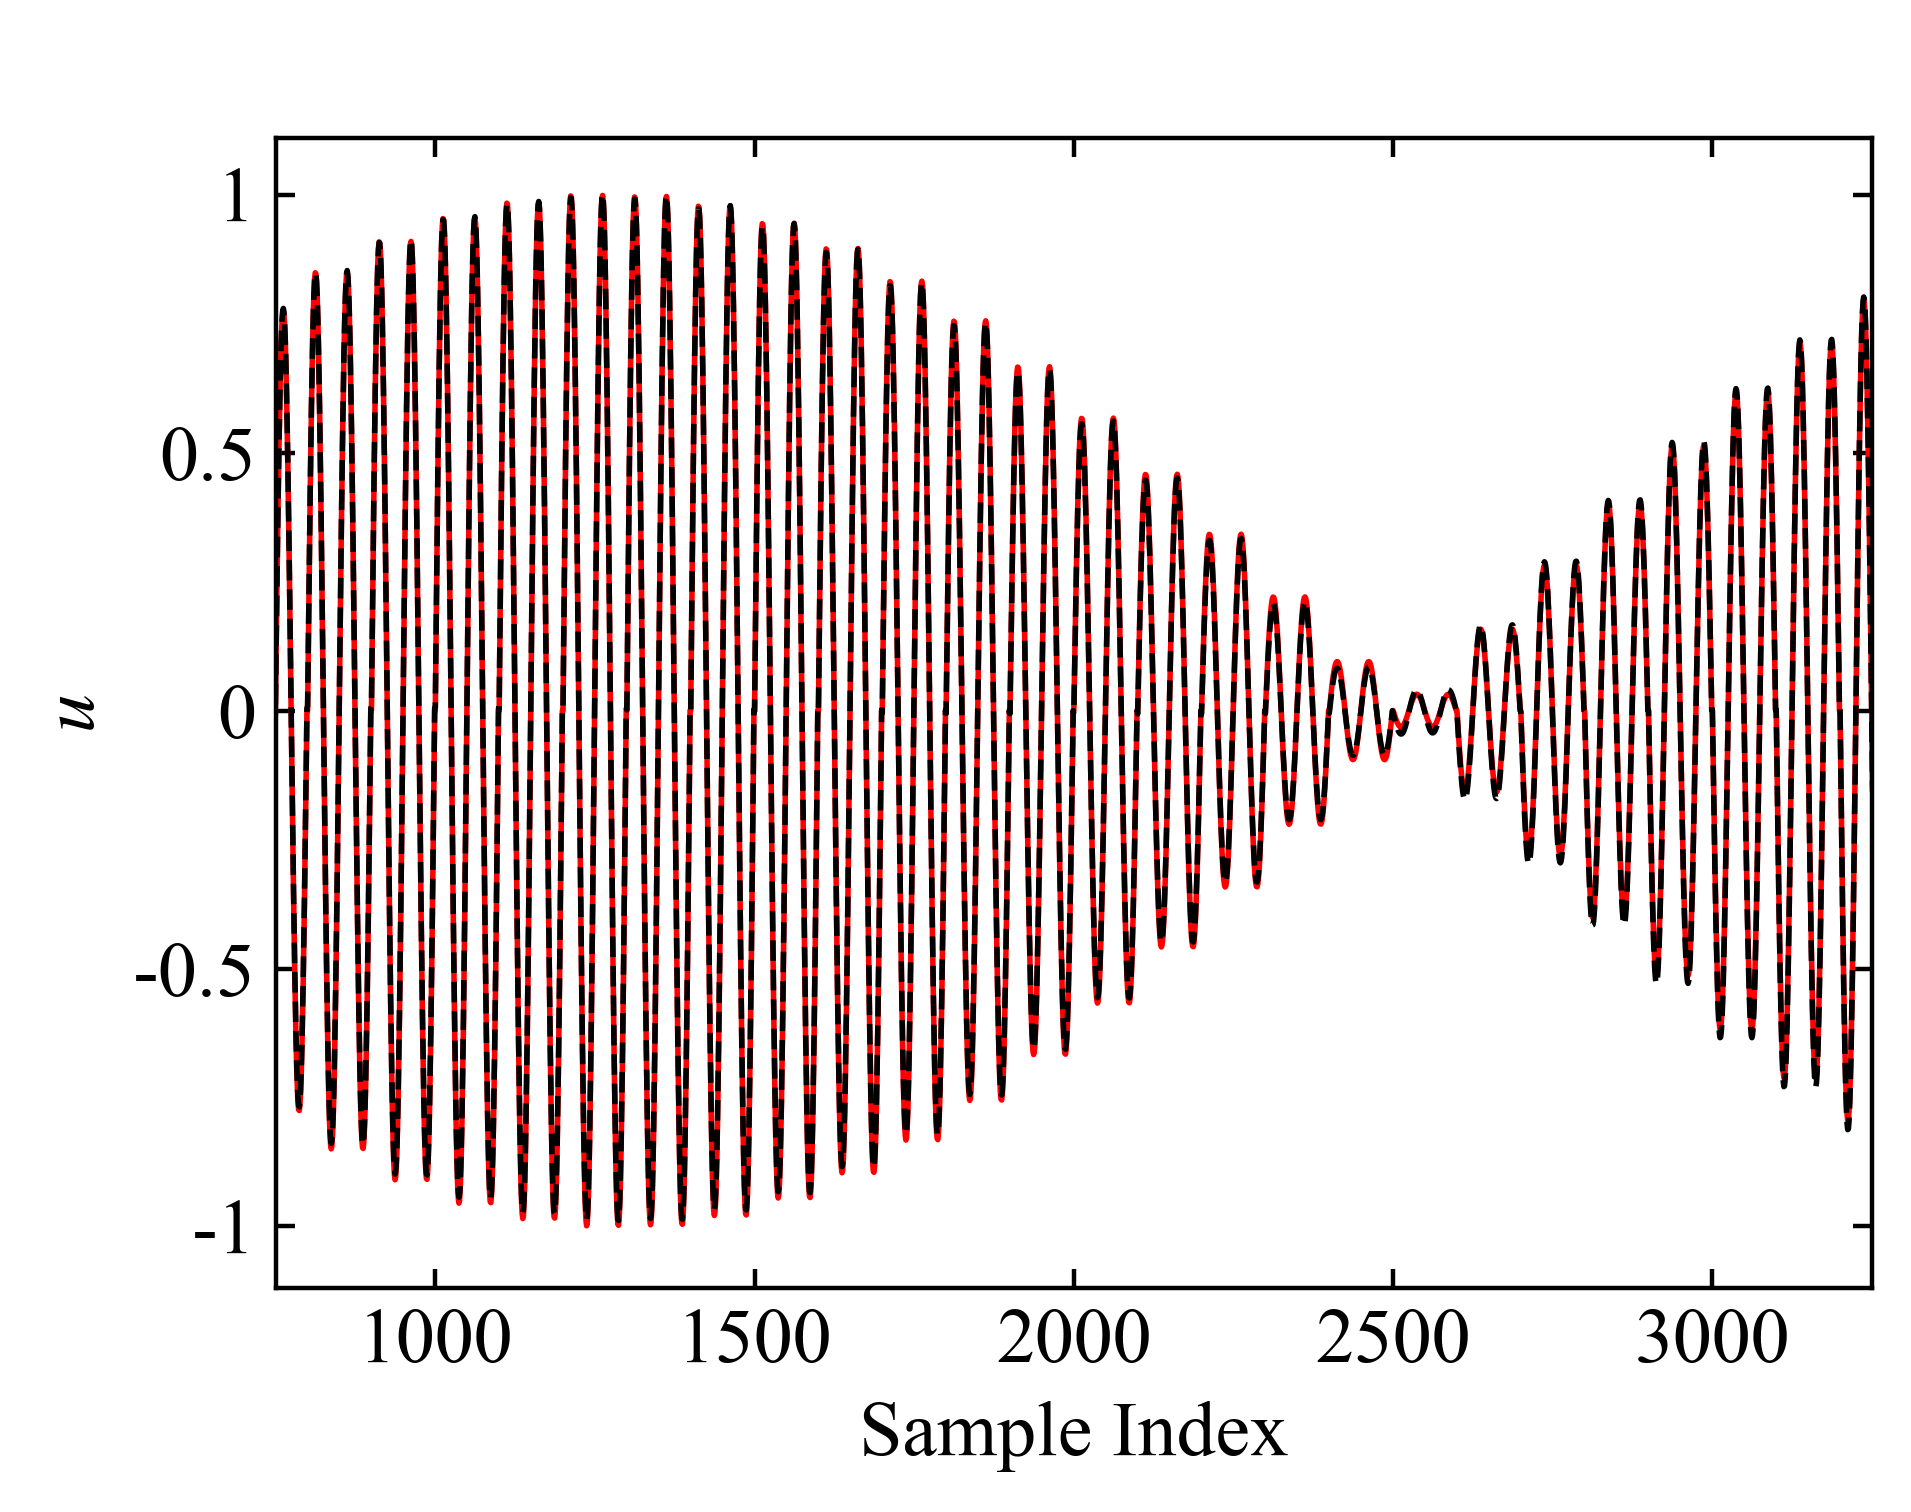

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter   # ★ 추가

# from colormaps import *

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.dpi'] = 400

condition_set = (4,10)

# 파일 경로에 맞게 수정하세요
exact = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/exact_LPA.txt', delimiter=',')
prediction = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/prediction_LPA.txt', delimiter=',')

# ★ 정수면 소수점 제거 포매터
def no_dot_if_int(v, pos):
    return f"{int(v)}" if float(v).is_integer() else f"{v:g}"
formatter = FuncFormatter(no_dot_if_int)

plt.figure(figsize=(5,4))
plt.plot(exact, label='Analytic', linestyle='-', linewidth=1., color='red')
plt.plot(prediction, label='PINN', linestyle='--', linewidth=1., color='black')
plt.xlabel('Sample Index')
plt.ylabel('$u$')
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.title('  ')
plt.xlim(750, 3250)
plt.legend(fontsize=10, loc='best', frameon=False, ncol=1).remove()

# ★ 포매터 적용 (plt만 사용)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()


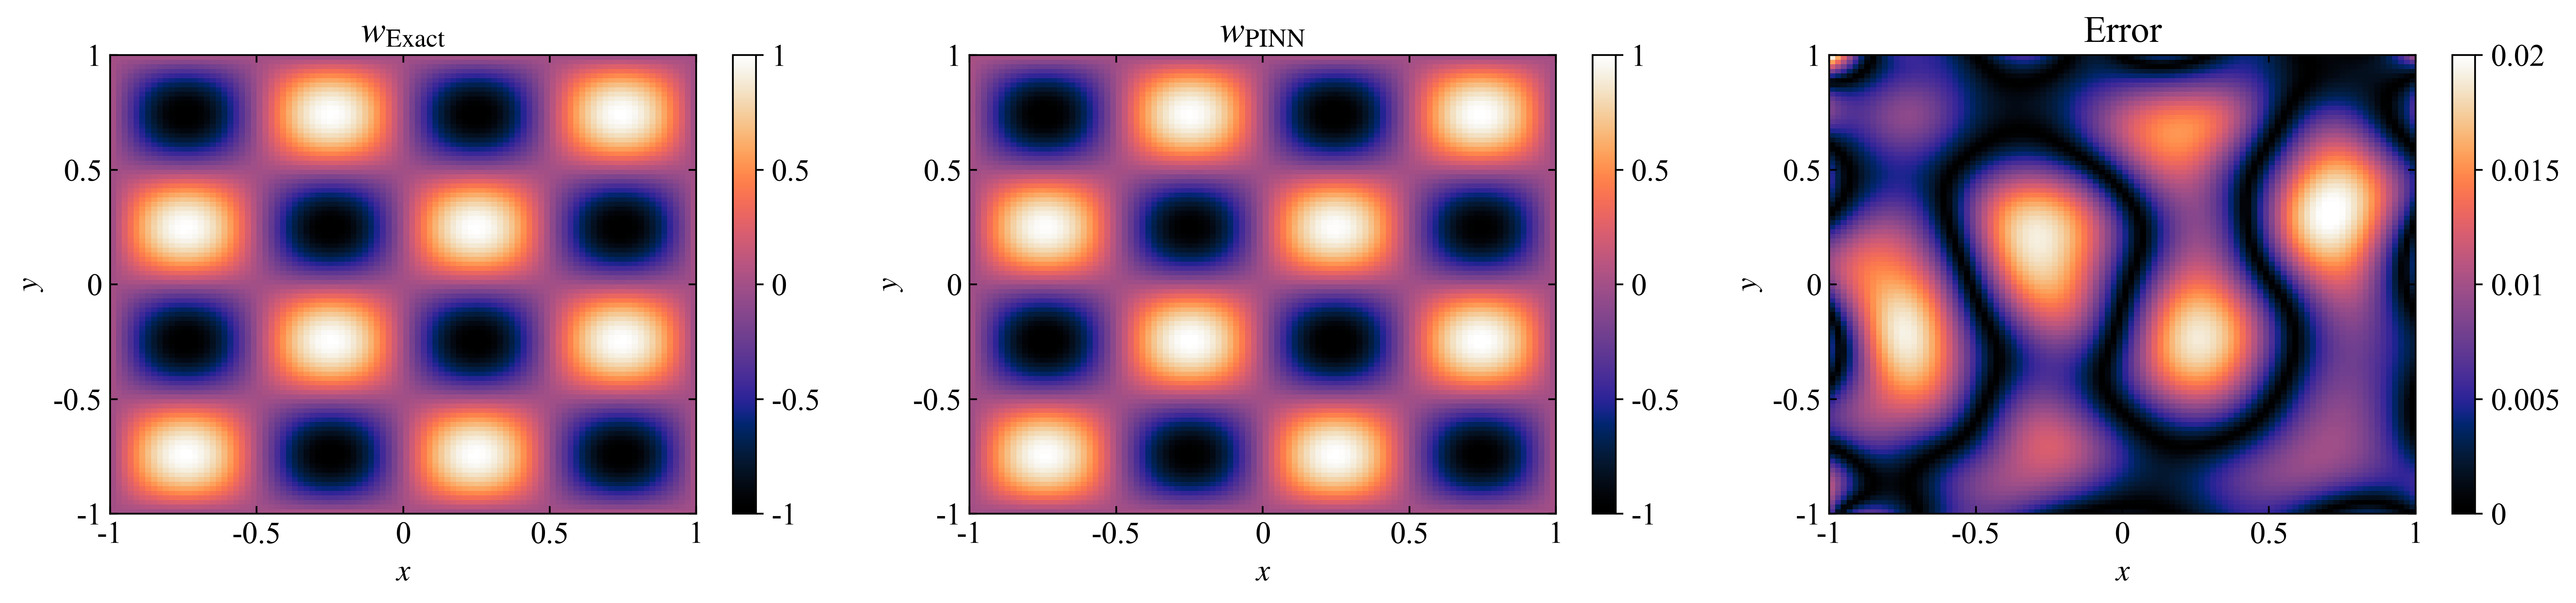

L1 error: 0.007192987950968071
L2 relative error: 0.017522054770712617


In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

exact = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/exact_LPA.txt', delimiter=',').flatten()
prediction = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/prediction_LPA.txt', delimiter=',').flatten()

nx, ny = 100, 100

exact = exact.reshape(nx, ny)
prediction = prediction.reshape(nx, ny)

#from colormaps import *

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 수학 표현에 대한 글꼴 설정
mpl.rcParams['font.size'] = 14  # 기본 글꼴 크기 설정
mpl.rcParams['figure.dpi'] = 400

cmap = 'jet'  # 기본 컬러맵 설정
import cmasher as cmaps
cmap = cmaps.torch
#cmap = cmap_4w_ROTB

def no_dot_if_int(x, pos):
    if float(x).is_integer():
        return f"{int(x)}"
    else:
        return f"{x:g}"

error = np.abs(exact - prediction)

plt.figure(figsize=(16.5,4))

# 1. Exact
plt.subplot(1,3,1)
im1 = plt.imshow(exact, aspect='auto', extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.title('$w_{\\mathrm{{Exact}}}$')
plt.xlabel('$x$', fontsize=14,)
plt.ylabel('$y$', fontsize=14,)
plt.xticks(np.linspace(-1, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.colorbar(im1, ticks=np.linspace(1, -1, 5))

# 2. Prediction
plt.subplot(1,3,2)
im2 = plt.imshow(prediction, aspect='auto', extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.title('$w_{\\mathrm{{PINN}}}$')
plt.xlabel('$x$', fontsize=14,)
plt.ylabel('$y$', fontsize=14,)
plt.xticks(np.linspace(-1, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.colorbar(im2, ticks=np.linspace(1, -1, 5))

# 3. Absolute Error
plt.subplot(1,3,3)
im3 = plt.imshow(error, aspect='auto', extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=0, vmax=.02)
plt.title('Error')
plt.xlabel('$x$', fontsize=14,)
plt.ylabel('$y$', fontsize=14,)
plt.xticks(np.linspace(-1, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
plt.colorbar(im3, ticks=np.linspace(0, .02, 5))

formatter = FuncFormatter(no_dot_if_int)

for ax in plt.gcf().axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print('L1 error:', np.mean(error))
print('L2 relative error:', np.linalg.norm(error) / np.linalg.norm(exact))

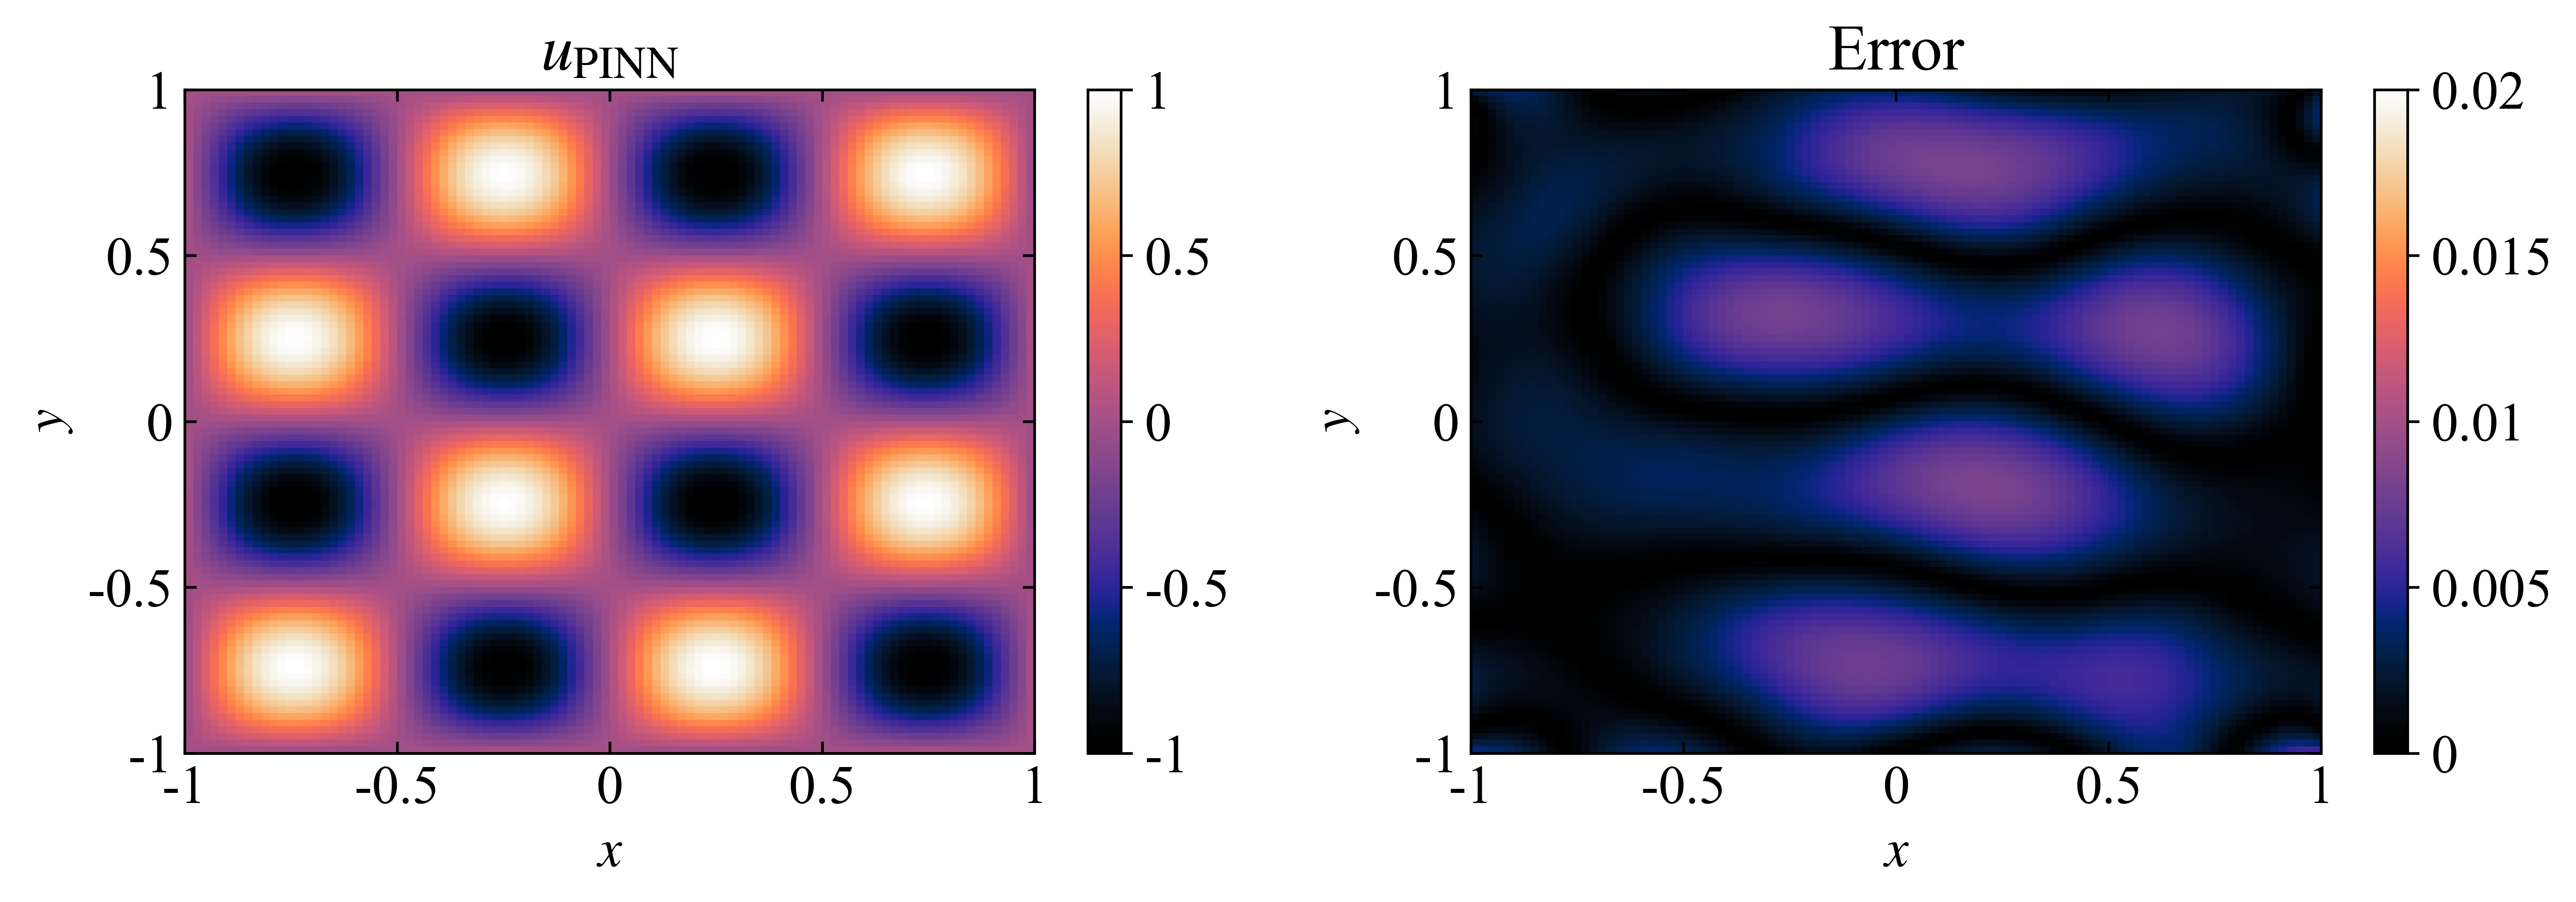

L1 error: 0.003029218797169581
L2 relative error: 0.0074791964814564585


In [37]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

condition_set = (3, 20)

exact = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/exact_LPA.txt', delimiter=',').flatten()
prediction = np.loadtxt(f'./results/{condition_set[0]}_{condition_set[1]}/LPA/prediction_LPA.txt', delimiter=',').flatten()

nx, ny = 100, 100

exact = exact.reshape(nx, ny)
prediction = prediction.reshape(nx, ny)

#from colormaps import *

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 수학 표현에 대한 글꼴 설정
mpl.rcParams['font.size'] = 16  # 기본 글꼴 크기 설정
mpl.rcParams['figure.dpi'] = 600

cmap = 'jet'  # 기본 컬러맵 설정
import cmasher as cmr
cmap = cmr.torch

def no_dot_if_int(x, pos):
    if float(x).is_integer():
        return f"{int(x)}"
    else:
        return f"{x:g}"

error = np.abs(exact - prediction)

plt.figure(figsize=(11,4))

# 2. Prediction
plt.subplot(1,2,1)
im2 = plt.imshow(prediction, aspect='auto', extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.title('$u_{\\mathrm{{PINN}}}$')
plt.xlabel('$x$', fontsize=16,)
plt.ylabel('$y$', fontsize=16,)
plt.xticks(np.linspace(-1, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=16, top=True, right=True)
plt.colorbar(im2, ticks=np.linspace(1, -1, 5))

# 3. Absolute Error
plt.subplot(1,2,2)
im3 = plt.imshow(error, aspect='auto', extent=[-1,1,-1,1], origin='lower', cmap=cmap, vmin=0, vmax=.02)
plt.title('Error')
plt.xlabel('$x$', fontsize=16,)
plt.ylabel('$y$', fontsize=16,)
plt.xticks(np.linspace(-1, 1, 5), [f'{i/4:.2f}' for i in range(5)])
plt.tick_params(axis='both', which='major', direction='in', labelsize=16, top=True, right=True)
plt.colorbar(im3, ticks=np.linspace(0, .02, 5))

formatter = FuncFormatter(no_dot_if_int)

for ax in plt.gcf().axes:
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print('L1 error:', np.mean(error))
print('L2 relative error:', np.linalg.norm(error) / np.linalg.norm(exact))

TypeError: 'Axes' object is not iterable

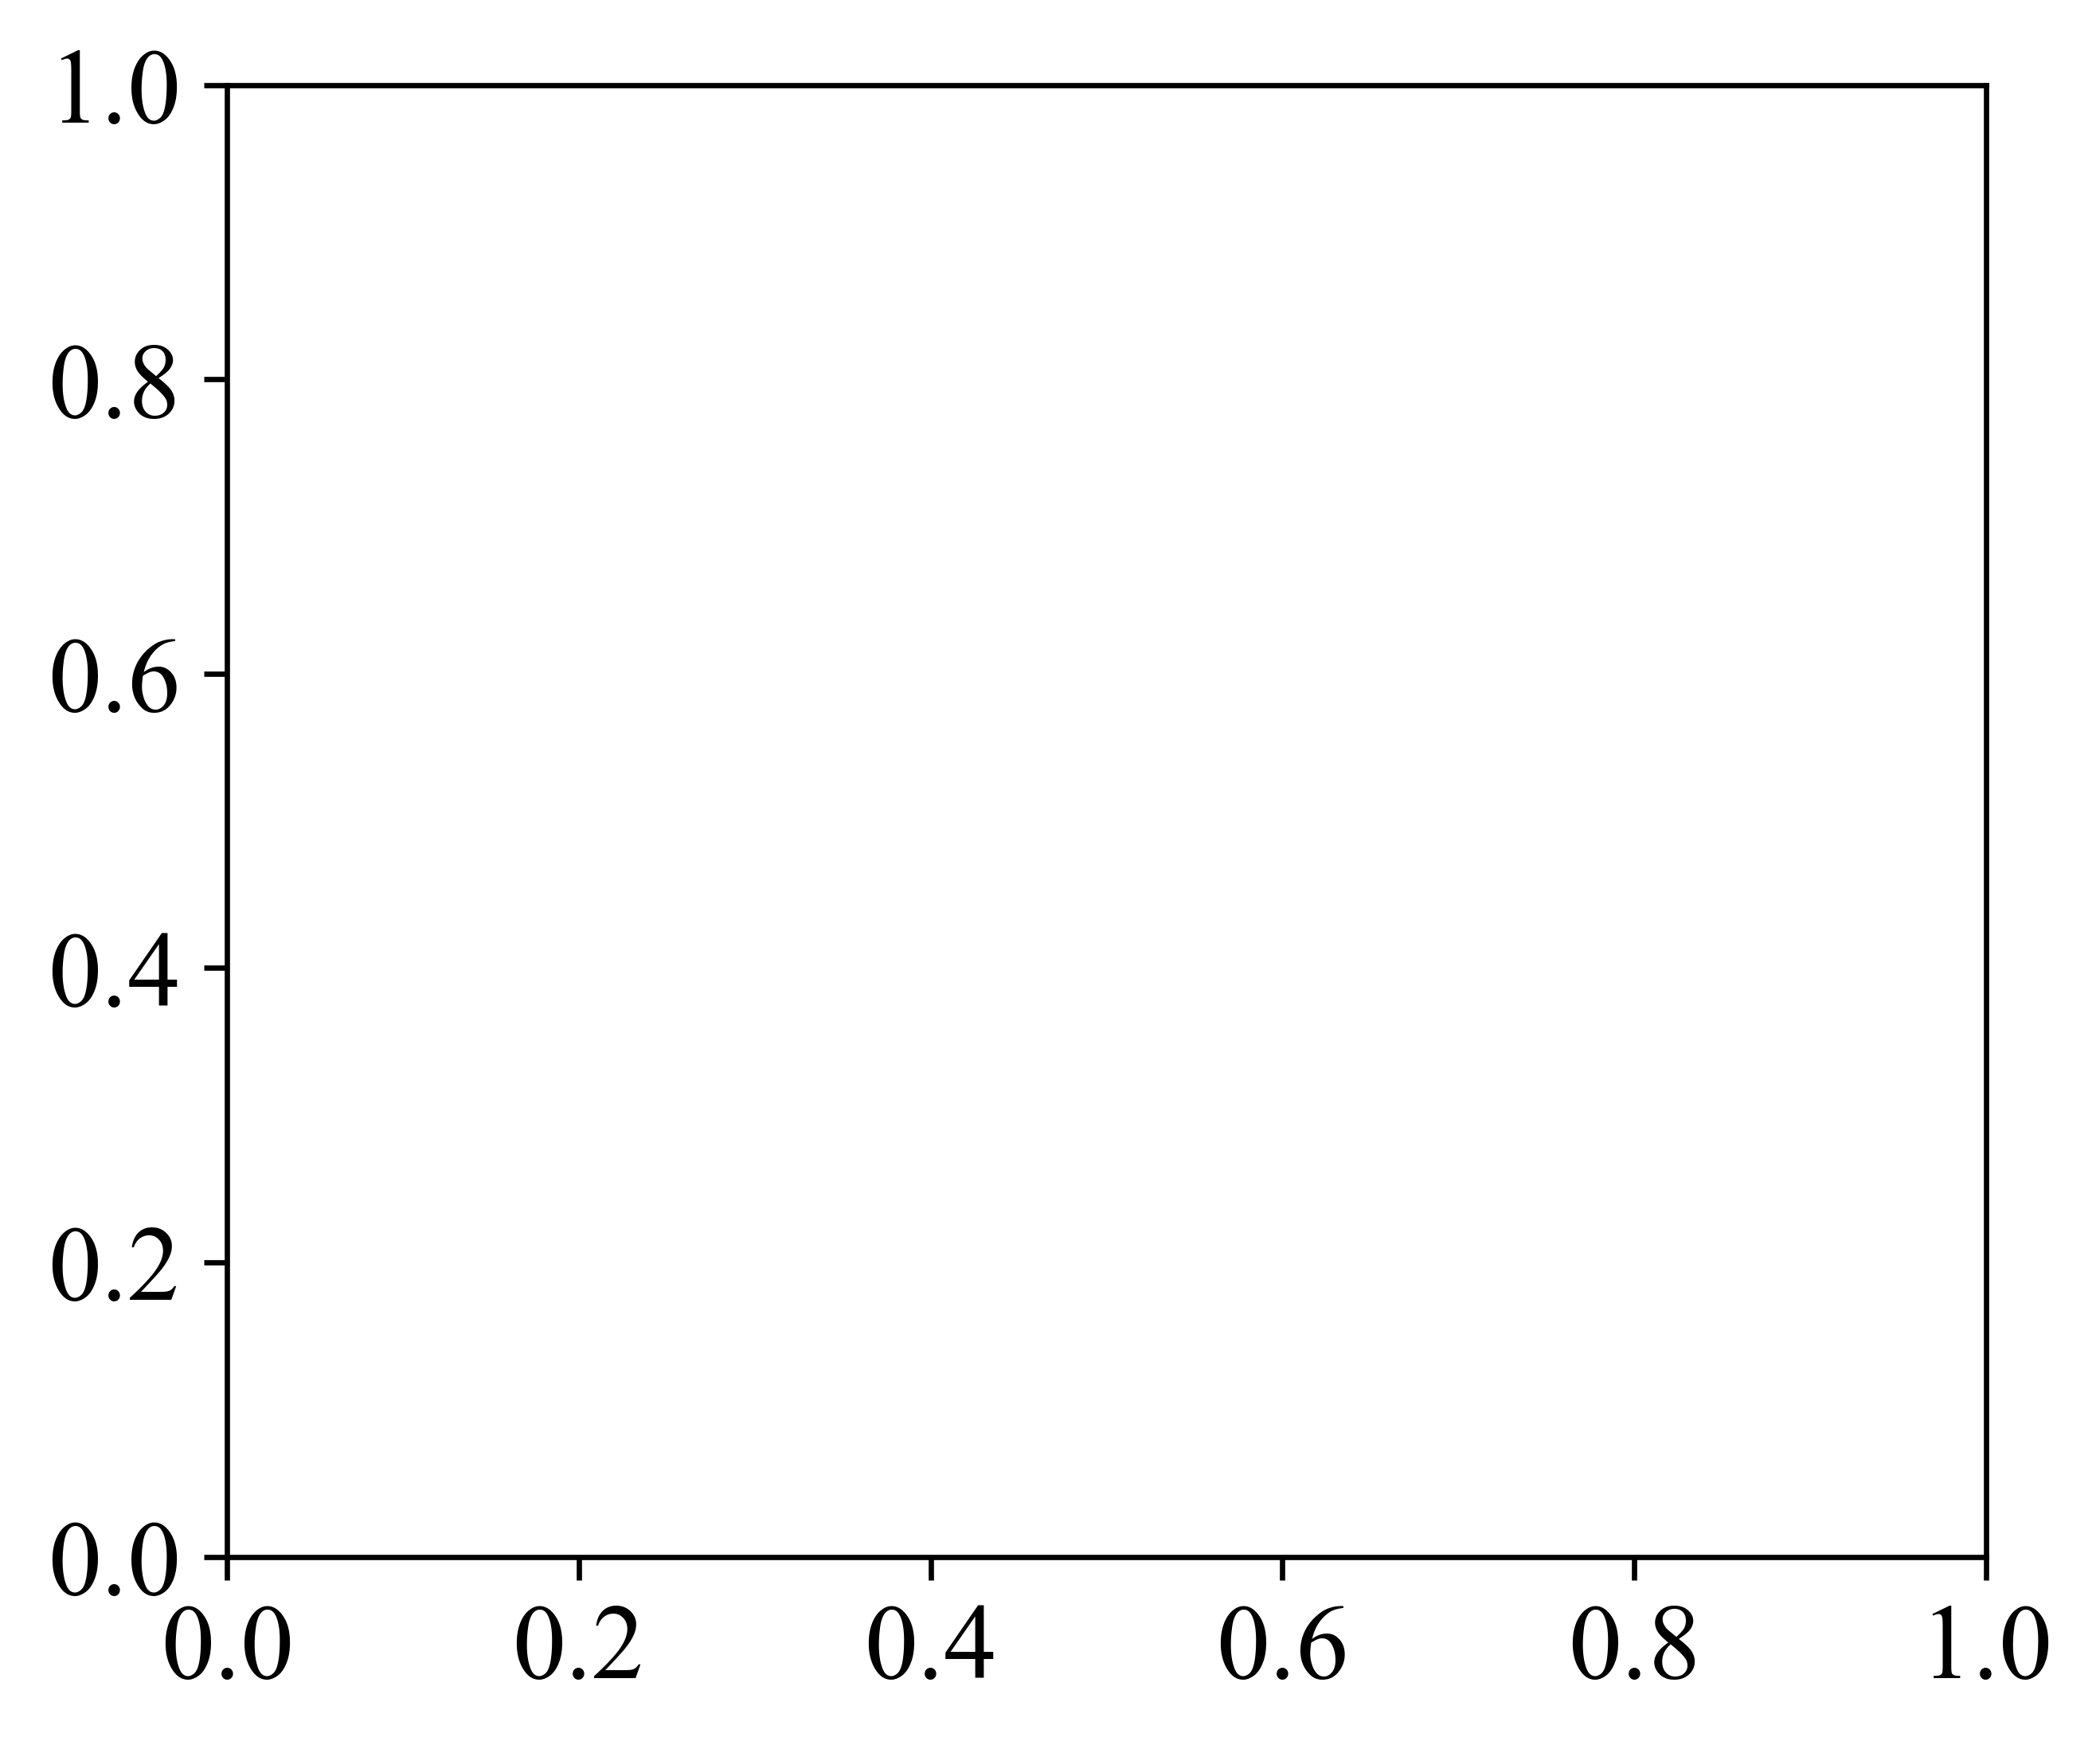

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from matplotlib.lines import Line2D

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.dpi'] = 600  # ★ 400 → 600으로 화질 향상


# 모델 trial 설정
model_keys = {
    'R': {'trials': range(0, 10), 'color': 'black'},
    'LPA $P_{2}$': {'trials': range(0, 5), 'color': 'blue'},
    'LPA $P_{3}$': {'trials': range(5, 10), 'color': 'red'},
    'LPA $P_{4}$': {'trials': range(10, 15), 'color': 'green'},
    'LPA $P_{5}$': {'trials': range(15, 20), 'color': 'orange'},
    'LPA $P_{6}$': {'trials': range(20, 25), 'color': 'purple'},
}

# 네트워크 구성 설정
configs = [(5,10)]

# ★ 각 subplot의 x축 최대값을 개별 지정
xlim_map = {
    (2, 10): 9500,
    (3, 10): 8500,
    (5, 10): 9000,   # (c)는 적절히 조정 (데이터 보고 수정 가능)
}

TICK_LABEL_SIZE = 16  # ★ tick label 크기

fig, axes = plt.subplots(1, len(configs), figsize=(4.75*len(configs), 4))

for ax, (layers, neurons) in zip(axes, configs):
    for model_name, setting in model_keys.items():
        best_l2 = np.inf
        best_l2_history = None

        for trial in setting['trials']:
            if model_name == 'R':
                fname = f'./results/acc_hist_{layers}_{neurons}_R_{trial}.txt'
            elif model_name == 'ADAF':
                fname = f'./results/acc_hist_{layers}_{neurons}_ADAF_{trial}.txt'
            else:
                fname = f'./results/acc_hist_{layers}_{neurons}_LPA_{trial}.txt'

            if not os.path.exists(fname):
                continue

            try:
                loss = np.loadtxt(fname, delimiter=',')
                if loss.ndim == 2 and loss.shape[1] >= 2:
                    l2_history = loss[:, 1]
                    final_l2 = l2_history[-1]
                    if final_l2 < best_l2:
                        best_l2 = final_l2
                        best_l2_history = l2_history
            except Exception as e:
                print(f"Error reading {fname}: {e}")

        if best_l2_history is not None:
            iterations = np.arange(len(best_l2_history)) * 50
            ax.plot(iterations, best_l2_history, label=model_name,
                    color=setting['color'], linestyle='-')

    ax.set_title(f'{layers} layers {neurons} neurons', fontsize=16)
    ax.set_xlabel('Iteration', fontsize=16)

    # ★ x축 범위를 subplot마다 개별 지정
    xmax = xlim_map.get((layers, neurons), None)
    ax.set_xlim(0, xmax)

    ax.set_ylim(4e-3, 4)
    ax.set_yscale('log')
    ax.grid(False)

    # ★ tick label size 키우기
    ax.tick_params(axis='both', which='major', direction='in',
                   labelsize=TICK_LABEL_SIZE, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in',
                   labelsize=TICK_LABEL_SIZE, left=False, top=False, right=False)

    ax.legend(fontsize=12, loc='best', frameon=False, ncol=1).remove()

axes[0].set_ylabel('L2 Relative Error', fontsize=16)

fig.tight_layout()

# 공통 legend를 figure 오른쪽 바깥에 배치
legend_handles = [
    Line2D([0], [0], lw=2, color=setting['color'], label=model_name)
    for model_name, setting in model_keys.items()
]

fig.legend(handles=legend_handles,
           loc='center',
           bbox_to_anchor=(1.025, 0.35),
           fontsize=12,
           frameon=False,
           ncol=1)

plt.show()

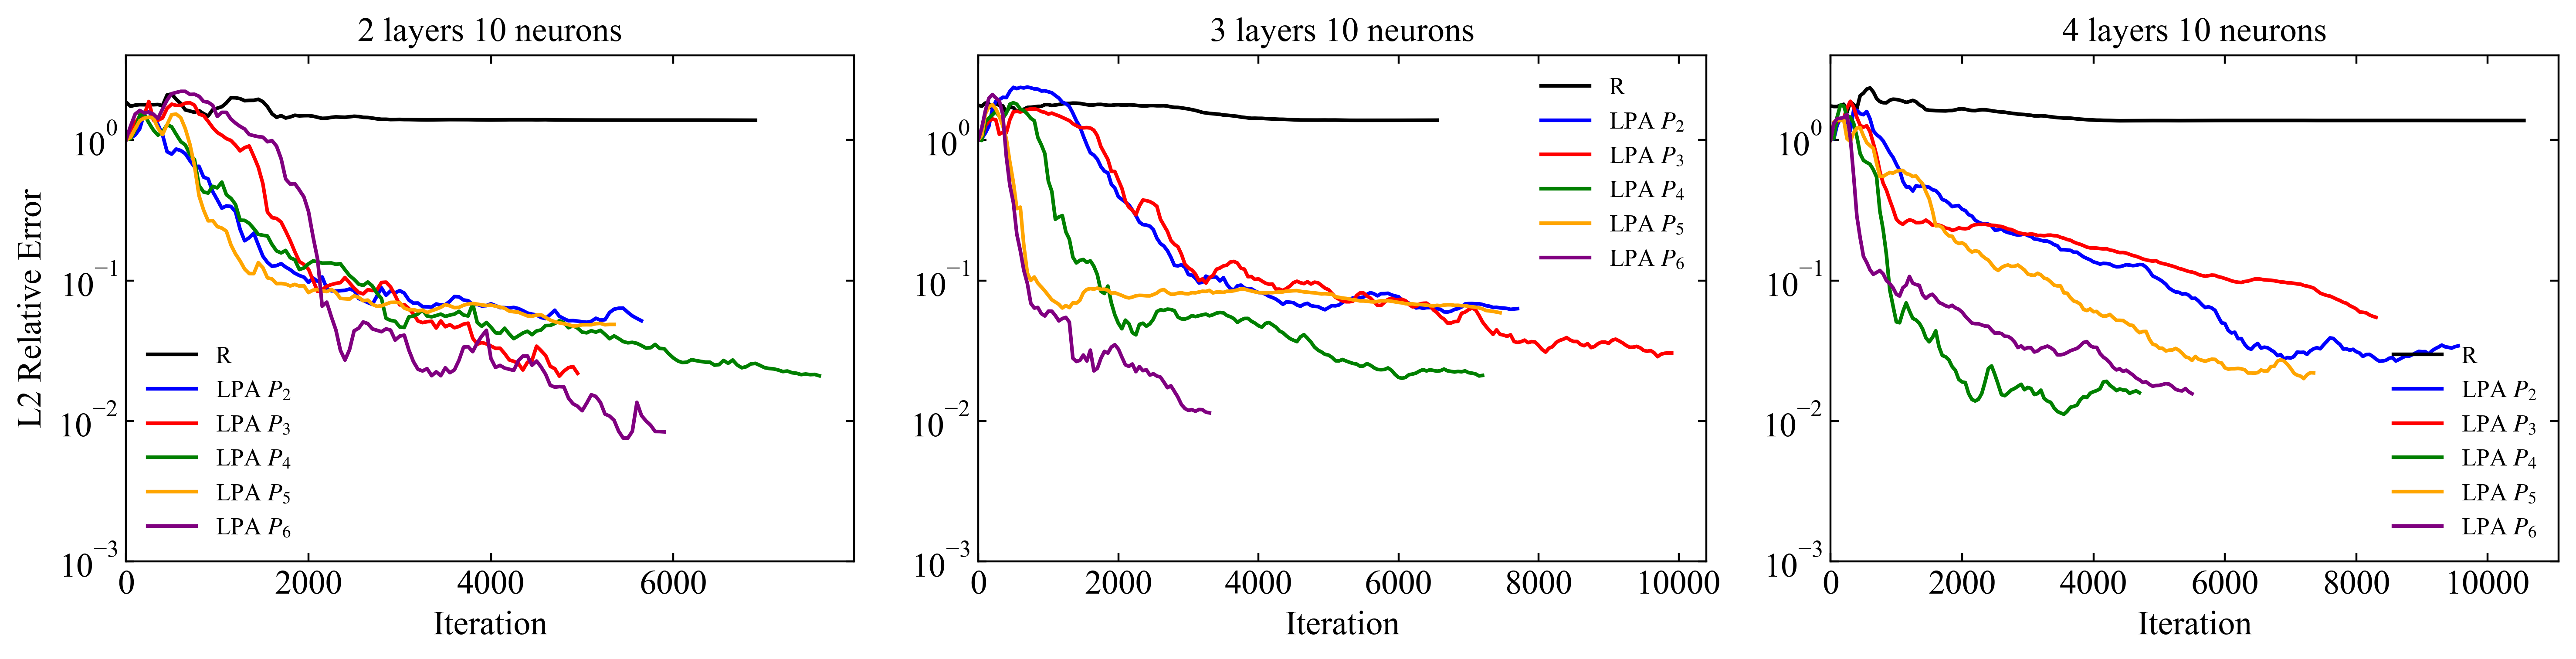

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'  # 수학 표현에 대한 글꼴 설정
mpl.rcParams['font.size'] = 14  # 기본 글꼴 크기 설정
mpl.rcParams['figure.dpi'] = 400


# 모델 trial 설정
model_keys = {
    'R': {'trials': range(0, 10), 'color': 'black'},
    #'ADAF':{'trials': range(0, 10), 'color': 'red'},
    'LPA $P_{2}$': {'trials': range(25, 30), 'color': 'blue'},
    'LPA $P_{3}$': {'trials': range(30, 35), 'color': 'red'},
    'LPA $P_{4}$': {'trials': range(35, 40), 'color': 'green'},
    'LPA $P_{5}$': {'trials': range(40, 45), 'color': 'orange'},
    'LPA $P_{6}$': {'trials': range(45, 50), 'color': 'purple'},
    #'LPA+gPINN': {'trials': range(10, 20), 'color': 'red'},
}

# 네트워크 구성 설정
configs = [(2, 10), (3, 10), (4, 10)]
#configs = [(2,20), (2,40), (2,60), (4,20), (4,40), (4,60)]

fig, axes = plt.subplots(1, len(configs), figsize=(5*len(configs), 4))

for ax, (layers, neurons) in zip(axes, configs):
    for model_name, setting in model_keys.items():
        best_l2 = np.inf
        best_l2_history = None

        for trial in setting['trials']:
            if model_name == 'R':
                fname = f'./results/acc_hist_{layers}_{neurons}_R_{trial}.txt'
            elif model_name == 'ADAF':
                fname = f'./results/acc_hist_{layers}_{neurons}_ADAF_{trial}.txt'
            else:
                fname = f'./results/acc_hist_{layers}_{neurons}_LPA_{trial}.txt'

            if not os.path.exists(fname):
                continue

            try:
                loss = np.loadtxt(fname, delimiter=',')
                if loss.ndim == 2 and loss.shape[1] >= 2:
                    l2_history = loss[:, 1]
                    final_l2 = l2_history[-1]
                    if final_l2 < best_l2:
                        best_l2 = final_l2
                        best_l2_history = l2_history
            except Exception as e:
                print(f"Error reading {fname}: {e}")

        if best_l2_history is not None:
            iterations = np.arange(len(best_l2_history)) * 50  # 🔥 50배 곱하기
            ax.plot(iterations, best_l2_history, label=model_name,
                    color=setting['color'], linestyle='-')

    ax.set_title(f'{layers} layers {neurons} neurons', fontsize=14)
    ax.set_xlabel('Iteration')
    ax.set_xlim(0,)
    ax.set_ylim(1e-3,4)
    ax.set_yscale('log')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=14, left=False)
    ax.legend(fontsize=10, loc='best', frameon=False, ncol=1)

axes[0].set_ylabel('L2 Relative Error')
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import os

# 기본 설정
result_dir = './results'
keys = ['R', 'LPA']
configs = [(2,10),(3,10),(4,10)]#[(2,20), (2,40), (2,60), (4,20), (4,40), (4,60)]

# 최저 L2 결과를 저장할 딕셔너리 초기화
# best_results[key][(layers, neurons)] = {
#     'trial': int,
#     'final_L1': float,
#     'final_L2': float,
#     'epochs': int,
#     'total_time': float,
#     'time_per_epoch': float
# }
best_results = {key: {} for key in keys}
for key in keys:
    for layers, neurons in configs:
        # 초기값: L2 무한대로 설정
        best = {
            'trial': None,
            'final_L1': None,
            'final_L2': np.inf,
            'epochs': None,
            'total_time': None,
            'time_per_epoch': None
        }

        # trial 0부터 9까지 반복
        for trial in range(10):
            acc_file = f'{result_dir}/acc_hist_{layers}_{neurons}_{key}_{trial}.txt'
            time_file = f'{result_dir}/cal_time_{layers}_{neurons}_{key}_{trial}.txt'

            # Accuracy 읽기
            if os.path.exists(acc_file):
                acc_hist = np.loadtxt(acc_file, delimiter=',')
                final_L1 = acc_hist[-1, 0]
                final_L2 = acc_hist[-1, 1]
                epochs = acc_hist.shape[0] * 50
            else:
                # 파일이 없으면 건너뜀
                continue

            # Time 읽기
            if os.path.exists(time_file):
                time_data = np.loadtxt(time_file, delimiter=',')
                total_time = np.sum(time_data)
                time_per_epoch = total_time / epochs if epochs else None
            else:
                # 시간 파일 없으면 None 처리
                total_time = None
                time_per_epoch = None

            # 현재 trial이 best L2 보다 좋으면 갱신
            if final_L2 is not None and final_L2 < best['final_L2']:
                best.update({
                    'trial': trial,
                    'final_L1': final_L1,
                    'final_L2': final_L2,
                    'epochs': epochs,
                    'total_time': total_time,
                    'time_per_epoch': time_per_epoch
                })

        best_results[key][(layers, neurons)] = best

# 출력
print("\n🔎 Best Results over trials 0–9 (lowest L2)\n")
header = f"{'Key':<5} {'Layers':>6} {'Neurons':>8} {'Trial':>6} {'L1 Error':>12} {'L2 Rel Error':>15} {'Epochs':>8} {'Total Time(s)':>15} {'Time/Epoch(s)':>15}"
print(header)
print("-" * len(header))

for key in keys:
    for (layers, neurons), res in best_results[key].items():
        if res['trial'] is not None:
            print(f"{key:<5} {layers:>6} {neurons:>8} {res['trial']:>6} "
                  f"{res['final_L1']:>12.3e} {res['final_L2']:>15.3e} "
                  f"{res['epochs']:>8} {res['total_time']:>15.2f} {res['time_per_epoch']:>15.4f}")
        else:
            print(f"{key:<5} {layers:>6} {neurons:>8} {'[no data]':>67}")



🔎 Best Results over trials 0–9 (lowest L2)

Key   Layers  Neurons  Trial     L1 Error    L2 Rel Error   Epochs   Total Time(s)   Time/Epoch(s)
--------------------------------------------------------------------------------------------------
R          2       10      5    3.177e-01       1.384e+00     6950           53.70          0.0077
R          3       10      5    3.182e-01       1.386e+00     6600           62.30          0.0094
R          4       10      1    3.163e-01       1.378e+00    10600          123.11          0.0116
LPA        2       10      5    1.106e-02       2.720e-02     5300           87.83          0.0166
LPA        3       10      8    7.896e-03       1.998e-02     5600          123.48          0.0220
LPA        4       10      8    4.727e-03       1.190e-02     4350          116.70          0.0268


In [8]:
import pandas as pd

# ==========================================
# 7. LPA+PINN vs PINN 결과 데이터 표 생성
# ==========================================

# 1) 데이터 수동 입력 (제공해주신 텍스트 기반)
# R -> PINN, LPA -> LPA+PINN
data_lpa = [
    ['PINN',      2, 10, 5, 3.177e-01, 1.384e+00, 6950, 53.70,  0.0077],
    ['PINN',      3, 10, 5, 3.182e-01, 1.386e+00, 6600, 62.30,  0.0094],
    ['PINN',      4, 10, 1, 3.163e-01, 1.378e+00, 10600, 123.11, 0.0116],
    ['LPA+PINN',  2, 10, 5, 1.106e-02, 2.720e-02, 5300, 87.83,  0.0166],
    ['LPA+PINN',  3, 10, 8, 7.896e-03, 1.998e-02, 5600, 123.48, 0.0220],
    ['LPA+PINN',  4, 10, 8, 4.727e-03, 1.190e-02, 4350, 116.70, 0.0268]
]

columns_lpa = ['Model', 'Layers', 'Neurons', 'Trial', 'L1 Error', 'L2 Rel Error', 'Epochs', 'Total Time(s)', 'Time/Epoch(s)']
df_lpa = pd.DataFrame(data_lpa, columns=columns_lpa)

# 2) 비교를 위한 피벗 테이블 생성 (Layers 기준)
# 주요 지표인 Relative L2 Error와 Total Time을 비교합니다.
pivot_lpa = df_lpa.pivot(index='Layers', columns='Model', values=['L2 Rel Error', 'Total Time(s)'])

# 컬럼 이름 및 순서 정리
# L2 Rel Error -> Rel. L2 Error, Total Time(s) -> Time (s)
pivot_lpa = pivot_lpa.rename(columns={'L2 Rel Error': 'Rel. $L^2$ Error', 'Total Time(s)': 'Time (s)'}, level=0)

# 컬럼 순서 재배치: [L2 Error (PINN, LPA), Time (PINN, LPA)]
desired_order = [
    ('Rel. $L^2$ Error', 'PINN'),
    ('Rel. $L^2$ Error', 'LPA+PINN'),
    ('Time (s)', 'PINN'),
    ('Time (s)', 'LPA+PINN')
]
pivot_lpa = pivot_lpa[desired_order]

print("=== PINN vs LPA+PINN Comparison Table (Neurons=10) ===")
display(pivot_lpa) # 숫자는 그대로 출력됨

# ==========================================
# 8. LaTeX 코드 생성
# ==========================================
print("\n" + "="*40)
print("=== LaTeX Table Code (LPA+PINN) ===")
print("="*40)

def sci_fmt(x):
    s = "{:.2e}".format(x)
    base, exponent = s.split('e')
    return f"${base} \\times 10^{{{int(exponent)}}}$"

def float_fmt(x):
    return f"{x:.2f}"

# 각 컬럼별 포맷 지정 (L2 Error는 과학적 표기, 시간은 소수점 2자리)
formatters_lpa = [sci_fmt, sci_fmt, float_fmt, float_fmt]

latex_code_lpa = pivot_lpa.to_latex(
    formatters=formatters_lpa,
    multicolumn=True,
    multicolumn_format='c',
    column_format='l' + 'c'*4,
    escape=False
)

print(latex_code_lpa)

=== PINN vs LPA+PINN Comparison Table (Neurons=10) ===


Rel. $L^2$ Error          Time (s)         
Model              PINN LPA+PINN     PINN LPA+PINN
Layers                                            
2                 1.384  0.02720    53.70    87.83
3                 1.386  0.01998    62.30   123.48
4                 1.378  0.01190   123.11   116.70


=== LaTeX Table Code (LPA+PINN) ===
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{Rel. $L^2$ Error} & \multicolumn{2}{c}{Time (s)} \\
Model & PINN & LPA+PINN & PINN & LPA+PINN \\
Layers &  &  &  &  \\
\midrule
2 & $1.38 \times 10^{0}$ & $2.72 \times 10^{-2}$ & 53.70 & 87.83 \\
3 & $1.39 \times 10^{0}$ & $2.00 \times 10^{-2}$ & 62.30 & 123.48 \\
4 & $1.38 \times 10^{0}$ & $1.19 \times 10^{-2}$ & 123.11 & 116.70 \\
\bottomrule
\end{tabular}



/var/folders/bw/9r0ymjsn7_ldzlg6vxg9t08r0000gn/T/ipykernel_37013/1147644334.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box = patches.Rectangle((0.15, y - 0.08), 0.5, 0.16, fill=True, color='#f8fbff',


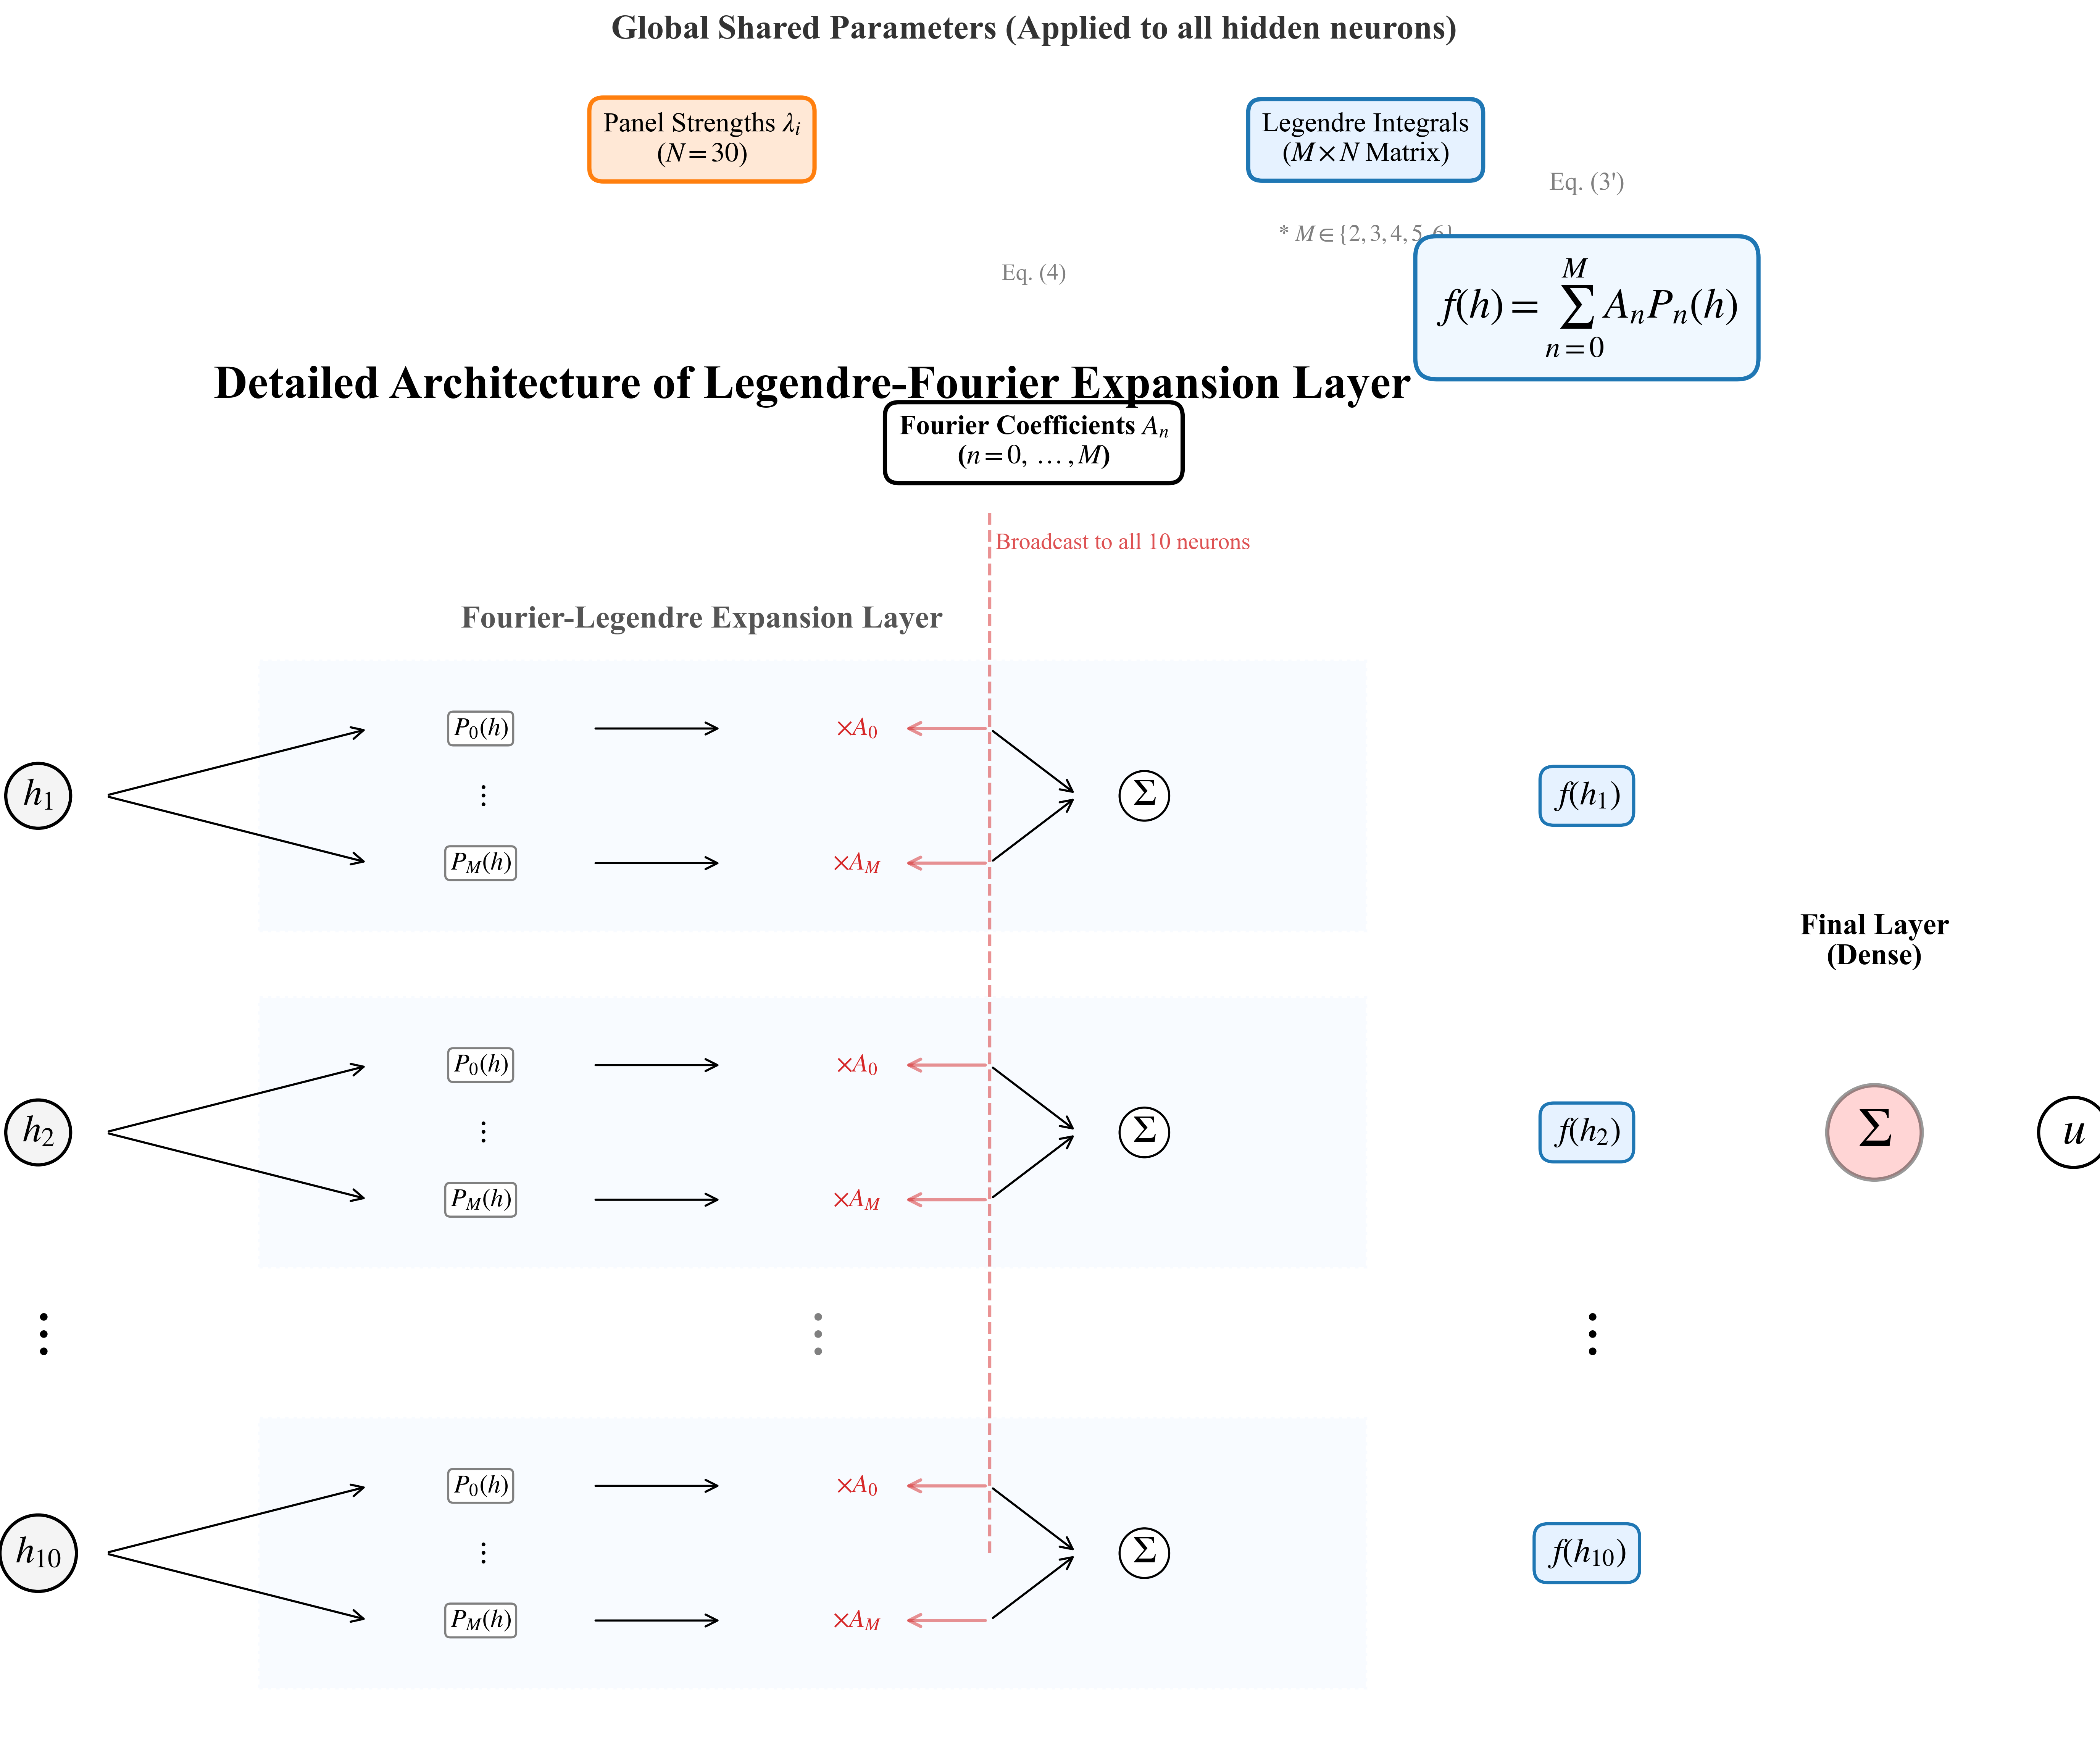

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(18, 12))
ax.axis('off')

# ==========================================
# 1. Global Shared Parameters (상단)
# ==========================================
# 제목 위치 상향
ax.text(0.5, 0.98, 'Global Shared Parameters (Applied to all hidden neurons)', 
        fontsize=16, weight='bold', ha='center', color='#333333')

# Lambda_i & C 박스 위치를 더 위로 올림 (y=0.92)
ax.text(0.35, 0.92, r'Panel Strengths $\lambda_i$' + '\n' + r'($N=30$)', ha='center', va='center', fontsize=13,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe8d6', edgecolor='#ff7f0e', lw=2))

ax.text(0.65, 0.92, r'Legendre Integrals' + '\n' + r'($M \times N$ Matrix)', ha='center', va='center', fontsize=13,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f2ff', edgecolor='#1f77b4', lw=2))
ax.text(0.65, 0.86, r'* $M \in \{2, 3, 4, 5, 6\}$', fontsize=11, ha='center', color='gray')

# TensorDot 화살표 시작점 조정
ax.annotate('', xy=(0.48, 0.83), xytext=(0.42, 0.90), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(0.52, 0.83), xytext=(0.58, 0.90), arrowprops=dict(arrowstyle='->', lw=1.5))

# Coefficients A_n 박스 위치를 아래로 내림 (y=0.74)
ax.text(0.5, 0.84, 'Eq. (4)', ha='center', va='center', fontsize=11, color='gray')
ax.annotate('', xy=(0.5, 0.78), xytext=(0.5, 0.82), arrowprops=dict(arrowstyle='->', lw=1.5))

ax.text(0.5, 0.74, r'Fourier Coefficients $A_n$' + '\n' + r'($n = 0, \dots, M$)', ha='center', va='center', fontsize=13, weight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', lw=2))

# ==========================================
# 2. Element-wise LPA Expansion (중단 ~ 하단)
# ==========================================
# y 포지션을 약간 아래로 조정하여 상단과 간격 확보
y_positions = [0.53, 0.33, 0.08]
neuron_labels = ['1', '2', '10']

ax.text(0.35, 0.63, 'Fourier-Legendre Expansion Layer', 
        fontsize=15, weight='bold', ha='center', color='#555555')

# Broadcasting Vertical Axis
ax.plot([0.48, 0.48], [0.08, 0.70], color='#d62728', linestyle='--', linewidth=1.5, alpha=0.5)
ax.text(0.48, 0.68, ' Broadcast to all 10 neurons', color='#d62728', fontsize=11, ha='left', va='center', alpha=0.8)

for i, (y, lbl) in enumerate(zip(y_positions, neuron_labels)):
    ax.text(0.05, y, f'$h_{{{lbl}}}$', fontsize=18, ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.4', facecolor='#f4f4f4', edgecolor='black', lw=1.5))
    
    box = patches.Rectangle((0.15, y - 0.08), 0.5, 0.16, fill=True, color='#f8fbff', 
                            edgecolor='#1f77b4', lw=1.5, ls=':', zorder=0)
    ax.add_patch(box)
    
    ax.text(0.25, y + 0.04, '$P_0(h)$', fontsize=12, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))
    ax.text(0.25, y - 0.04, '$P_M(h)$', fontsize=12, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray'))
    ax.text(0.25, y, r'$\vdots$', fontsize=14, ha='center', va='center')
    
    ax.annotate('', xy=(0.2, y+0.04), xytext=(0.08, y), arrowprops=dict(arrowstyle='->', lw=1))
    ax.annotate('', xy=(0.2, y-0.04), xytext=(0.08, y), arrowprops=dict(arrowstyle='->', lw=1))
    
    ax.text(0.42, y + 0.04, r'$\times A_0$', fontsize=12, ha='center', va='center', color='#d62728')
    ax.text(0.42, y - 0.04, r'$\times A_M$', fontsize=12, ha='center', va='center', color='#d62728')
    ax.annotate('', xy=(0.36, y+0.04), xytext=(0.3, y+0.04), arrowprops=dict(arrowstyle='->', lw=1))
    ax.annotate('', xy=(0.36, y-0.04), xytext=(0.3, y-0.04), arrowprops=dict(arrowstyle='->', lw=1))
    
    ax.annotate('', xy=(0.44, y+0.04), xytext=(0.48, y+0.04), arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5, alpha=0.5))
    ax.annotate('', xy=(0.44, y-0.04), xytext=(0.48, y-0.04), arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5, alpha=0.5))
    
    ax.text(0.55, y, r'$\Sigma$', fontsize=18, ha='center', va='center', 
            bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black'))
    ax.annotate('', xy=(0.52, y), xytext=(0.48, y+0.04), arrowprops=dict(arrowstyle='->', lw=1))
    ax.annotate('', xy=(0.52, y), xytext=(0.48, y-0.04), arrowprops=dict(arrowstyle='->', lw=1))
    
    ax.annotate('', xy=(0.7, y), xytext=(0.58, y), arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.text(0.75, y, f'$f(h_{{{lbl}}})$', fontsize=16, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e6f2ff', edgecolor='#1f77b4', lw=1.5))

# 뉴런 생략 기호 위치 조정
ax.text(0.05, 0.21, r'$\vdots$', fontsize=28, ha='center', va='center')
ax.text(0.4, 0.21, r'$\vdots$', fontsize=28, ha='center', va='center', color='gray')
ax.text(0.75, 0.21, r'$\vdots$', fontsize=28, ha='center', va='center')

# ==========================================
# 3. Eq (3') Box
# ==========================================
# 위치 조정
equation = r"$f(h) = \sum_{n=0}^{M} A_n P_n(h)$"
ax.text(0.75, 0.82, equation, fontsize=20, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f8ff', edgecolor='#1f77b4', lw=2))
ax.text(0.75, 0.89, 'Eq. (3\')', fontsize=12, ha='center', color='gray')

# ==========================================
# 4. Final Dense Layer
# ==========================================
# 위치 조정
ax.text(0.88, 0.43, 'Final Layer\n(Dense)', ha='center', weight='bold', fontsize=14)
ax.text(0.88, 0.33, r'$\Sigma$', fontsize=26, ha='center', va='center',
        bbox=dict(boxstyle='circle,pad=0.4', facecolor='#ff9896', alpha=0.4, edgecolor='black', lw=2))

for y in y_positions:
    ax.annotate('', xy=(0.85, 0.33), xytext=(0.8, y), arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

ax.text(0.97, 0.33, '$u$', fontsize=22, ha='center', va='center',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', lw=1.5))
ax.annotate('', xy=(0.94, 0.33), xytext=(0.91, 0.33), arrowprops=dict(arrowstyle='->', lw=2))

plt.title(r'Detailed Architecture of Legendre-Fourier Expansion Layer', 
          fontsize=22, weight='bold', pad=25)

plt.tight_layout()
plt.savefig('LPA_Detailed_Architecture_Final_Fixed.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
print("Hellow World!")

Hellow World!
